In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Master's Thesis/TM Project/"

/content/drive/MyDrive/Master's Thesis/TM Project


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# !pip install scikit-optimize

In [5]:
# from skopt import gp_minimize
# from skopt import space

In [7]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [8]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 50) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.2
n_core = 1.7
n_cladding = 1

In [9]:
study = 'TM'
field_type = 'E'

In [10]:
reference_device = devices.SlabWaveguide(n_substrate, n_core, n_cladding, lambd, core_length, substrate_length, cladding_length, study=study, field_type=field_type)

TypeError: SlabWaveguide.__init__() got multiple values for argument 'study'

In [ ]:
memory_type = torch.device('cuda')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 2

In [ ]:
base_model = models.discontinuity_capturing_network(1, 256, num_modes, 1, 'DRBF')
# base_model = models.vanilla_network(1, 256, num_modes, 1, 'RBF')
optimzer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[2000, 3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 1538


In [ ]:
device = devices.SlabWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, core_length, substrate_length, cladding_length, study, field_type, base_model, True)

In [ ]:
train_agent = trainer.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimzer, scheduler, dx)

In [ ]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[10, 0.5, 2, 1, 1, 1], verbose=1, sample_new=False)

num PDE samples 699
num rayleigh samples 699
iteration 1 loss1 is 0.13943, loss2 is 0.69453, loss3 is -2.81313, loss4 is 3e-05, loss5 is 0.08238, loss6 is 1.04945
mode errors
**********
NN vs analytic
relative error for mode 0 is 132.67324%
**********
**********
NN vs analytic
relative error for mode 1 is 134.89131%
**********
iteration 1001 loss1 is 0.00845, loss2 is 0.01707, loss3 is -4.16811, loss4 is 0.00011, loss5 is 0.00058, loss6 is 0.18313
mode errors
**********
NN vs analytic
relative error for mode 0 is 4.73485%
**********
**********
NN vs analytic
relative error for mode 1 is 7.52166%
**********
iteration 2001 loss1 is 0.00826, loss2 is 2e-05, loss3 is -4.16156, loss4 is 5e-05, loss5 is 0.00081, loss6 is 0.09134
mode errors
**********
NN vs analytic
relative error for mode 0 is 4.14056%
**********
**********
NN vs analytic
relative error for mode 1 is 6.86194%
**********
iteration 3001 loss1 is 0.00261, loss2 is 0.00077, loss3 is -4.16566, loss4 is 0.0, loss5 is 0.0005, loss

In [ ]:
fd_device = devices.SlabWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, core_length, substrate_length, cladding_length, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u))

mode errors
**********
NN vs analytic
relative error for mode 0 is 0.95071%
**********
**********
NN vs analytic
relative error for mode 1 is 1.67881%
**********


[0.950709097081213, 1.6788121266196627]

evalution points are at an error of 0.0%


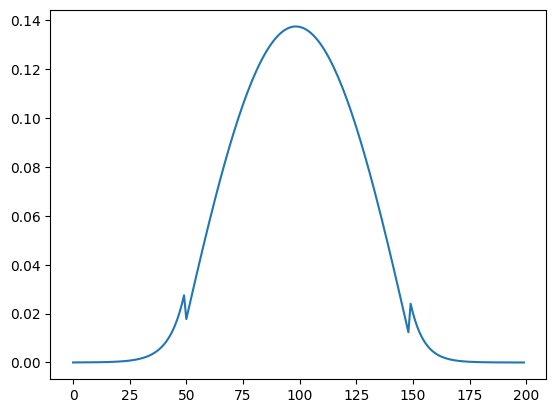

In [ ]:
mode_errors = []
num_modes = len(u.T)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)

if reference_device.study == 'TM':
  evaluation_pts_error = (torch.mean((torch.from_numpy(evaluation_points).reshape(-1) - x.reshape(-1)) ** 2) / np.mean(
          evaluation_points.reshape(-1) ** 2)) ** 0.5 * 100
  print(f'evalution points are at an error of {round(evaluation_pts_error.item(), 5)}%')

  if reference_device.field_type=='E':
    # plt.plot(eigen_funcs_analytic[0, 200:400])
    eigen_funcs_analytic = eigen_funcs_analytic / device.refractive_index(evaluation_points, format='numpy')**2
  # eigen_funcs_analytic = eigen_funcs_analytic.T
    eigen_funcs_analytic /= np.linalg.norm(eigen_funcs_analytic, axis=-1, keepdims=True)
    plt.plot(eigen_funcs_analytic[0, 250:450])
    # plt.plot((device.refractive_index(evaluation_points, format='numpy')**2)[200:400])

mode errors
**********
NN vs analytic
relative error for mode 0 is 0.37308%
**********
**********
NN vs analytic
relative error for mode 1 is 0.91415%
**********


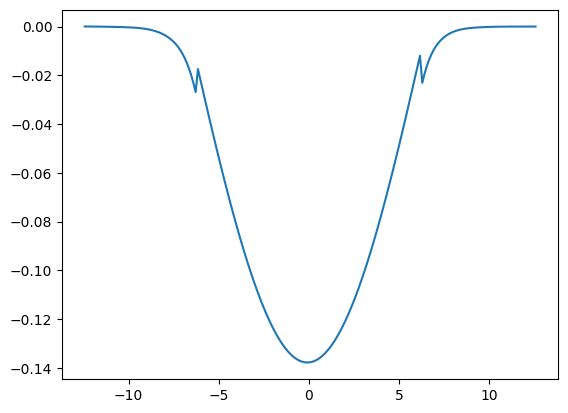

In [ ]:
augmented_x = torch.cat((torch.from_numpy(evaluation_points).reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)
predictions = device.underlying_model(augmented_x)
prediction_normed = predictions.detach().cpu() / torch.linalg.norm(predictions.detach().cpu(), dim=0, keepdims=True)

utils.compare_against_analytic(reference_device, x, predictions.detach().cpu())

plt.plot(evaluation_points[250:450], prediction_normed[250:450, 0].detach());

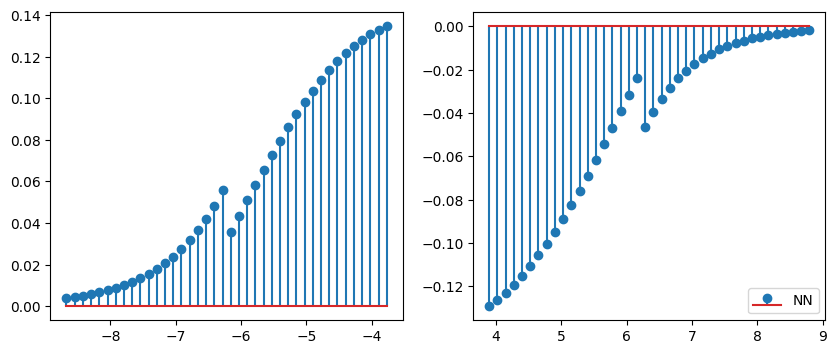

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(evaluation_points[280:320], prediction_normed[280:320, 1].detach(), label='NN');
plt.subplot(1, 2, 2)
plt.stem(evaluation_points[380:420], prediction_normed[380:420, 1].detach(), label='NN');
# plt.stem(evaluation_points[250:450], eigen_funcs_analytic[1, 250:450], label='analytic')
plt.legend();

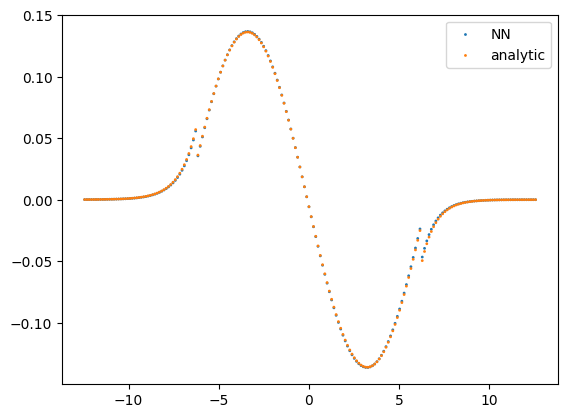

In [ ]:
plt.scatter(evaluation_points[250:450], prediction_normed[250:450, 1].detach(), label='NN', linestyle='dashed', s=1);
plt.scatter(evaluation_points[250:450], eigen_funcs_analytic[1, 250:450], label='analytic', linestyle='dashed', s=1)
plt.legend();

In [ ]:

x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), device.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)

In [ ]:
_**(1/2), fd_device.evaluate_analytical(x, 1)[1], device.calculate_eigen_value(x_augmented.to(memory_type), 0)**(1/2)

(array([1.68305023, 1.63153231]),
 array([1.68336482]),
 tensor(1.6834, device='cuda:0', dtype=torch.float64, grad_fn=<PowBackward0>))

In [ ]:
mode = fd_device.evaluate_analytical(x, 1)[2][0]
mode = mode.reshape(-1)
delta_mode = mode[1:] - mode[:-1]
derivative_mode = delta_mode / dx
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print(discontinuities_indices)
print((n_core**2)/(n_substrate**2), (n_cladding**2)/(n_core**2))
print(derivative_mode[295:305]/derivative_mode[296:306])
print(derivative_mode[395:405]/derivative_mode[396:406])


[tensor(299), tensor(399)]
2.006944444444444 0.34602076124567477
[0.86212648 0.86212648 0.86212648 0.46383275 1.00389364 1.00480534
 1.00572666 1.00665943 1.00760556 1.00856705]
[0.99550455 0.99640623 0.99730225 3.13955681 1.18550313 1.18550313
 1.18550313 1.18550313 1.18550313 1.18550313]


In [ ]:
mode = fd_device.evaluate_analytical(x, 1)[2][0]
mode = mode.reshape(-1)
mode = mode/device.refractive_index(torch.from_numpy(x).reshape(-1), format='numpy')**2
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print(discontinuities_indices)
print((n_core**2)/(n_substrate**2), (n_cladding**2)/(n_core**2))
print(mode[395:405]/mode[396:406])
print(mode[295:305]/mode[296:306])

[tensor(299), tensor(399)]
2.006944444444444 0.34602076124567477
[1.19680411 1.24640541 1.3285402  0.51600907 1.18550313 1.18550313
 1.18550313 1.18550313 1.18550313 1.18550313]
[0.86212648 0.86212648 0.86212648 0.86212648 1.54707805 0.81416725
 0.84392172 0.86565879 0.88226018 0.8953745 ]


In [ ]:
prediction_normed_tensor = prediction_normed[:, 0]
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print(discontinuities_indices)
print((n_core**2)/(n_substrate**2), (n_cladding**2)/(n_core**2))
print(prediction_normed_tensor[295:305]/prediction_normed_tensor[296:306])
print(prediction_normed_tensor[395:405]/prediction_normed_tensor[396:406])


[tensor(299), tensor(399)]
2.006944444444444 0.34602076124567477
tensor([0.8596, 0.8594, 0.8596, 0.8603, 1.5416, 0.8116, 0.8415, 0.8637, 0.8807,
        0.8942], dtype=torch.float64)
tensor([1.2018, 1.2529, 1.3369, 0.5189, 1.1897, 1.1914, 1.1918, 1.1910, 1.1895,
        1.1877], dtype=torch.float64)
